# Power-Based Side Channel Attacks 

Hello and welcome to our course about side channel attacks using the teem emulator. While we will delve into multiple different attacks, we will begin by explaining the power model of our emulator and show you the basic properties that are going to be exploited by these attacks. 

## Setup 

First, let's begin by making sure that the required dependencies for running the emulator as well as this notebook are installed. To do so please execute the code block below.

In [ ]:
%matplotlib widget 
import numpy as np 
import matplotlib.pyplot as plt
from benedict import benedict 
from src.power import CPAAttack, TraceViewer
from src.cpu import CPU

viewer = TraceViewer()

# Setting up the AES implementation

Everything you need is already bundled in the `micro-aes-template/` directory: the [micro-AES](https://github.com/polfosol/micro-AES) sources, the emulator header `cpuemu.h` (already `#include`d), a `Makefile`, and a `main.c` stub. You do **not** need to clone or copy anything — the setup that earlier versions of this exercise did by hand is already done for you.

Compilation uses the `riscv-clang` Docker image. You will run the compile command from a **host shell** (not from inside JupyterLab) once you have instrumented the code in the next step.

## Note

If you are using a Windows installation, you will find a pre-compiled version of programs you can work with in the demo-power directory. Just note that you will not have the full experience and will not be able to evaluate all aspects of the emulator later on.

## Starting Point

The template ships an uninstrumented `micro-aes-template/main.c` stub. Open it and fill in your encryption call. The original stub keeps the following guidance:

```c
#include "cpuemu.h"
#include "micro_aes.c" // We need to include the C file, because we are only going to the assembly stage and are not linking.
#include "micro_aes.h"
#include <stdint.h>

int main() {
  // For ease of use we recommend working with AES_ECB_encrypt. You can also use AES_CBC_encrypt, but you will
  // have to modify the leakage model with the IV bytes put in if you want to attack AES_CBC.
  // You should also chose the key for yourself because it is easier to see if your attack
  // worked if you know what the solution should be.
  //
  // There are several utility functions in cpuemu.h you can and should use (for example hex2bytes to convert a hex string to a byte
  // array.
  return 0;
}
```

When attacking an AES implementation via power-based side channel attacks, we are only really interested in a very specific part of the execution, namely the first round of the AES encryption and, specifically, the `SubBytes` step. Please search the micro-AES implementation for the `SubBytes` function and modify it with the syscalls `trace_start` and `trace_stop` to capture the relevant part of the AES execution (It is easier if you limit your capture to the first round of AES only). For documentation of these syscalls please look into the cpuemu.h file.

## Compile

Once `main.c` is filled in and `SubBytes` is instrumented, compile the template from a **host shell** (run this in your normal terminal, in the repository root — not in a JupyterLab terminal):

```sh
docker run --rm -v "$(pwd)/micro-aes-template":/work ghcr.io/jheinzde/teem-exercise/riscv-clang:latest
```

This writes the assembled `micro-aes-template/main.s` back to your host. To recompile after a change, clean first:

```sh
docker run --rm -v "$(pwd)/micro-aes-template":/work ghcr.io/jheinzde/teem-exercise/riscv-clang:latest clean
docker run --rm -v "$(pwd)/micro-aes-template":/work ghcr.io/jheinzde/teem-exercise/riscv-clang:latest
```

# Execution and first traces

Now that we have successfully compiled the AES implementation, we should try out what happens when we execute it in the emulator. To execute the program we have 2 options: we can either programmatically call the emulator from this Jupyter notebook, or we can use the provided CLI interface called headless_main.py. If you want to use the CLI interface you can just run it like this: `python headless_main.py <path-to-your-assembled-c-program>`. If you want to use the emulator from Jupyter please use the code cell provided below, but you will need to uncomment the codeblock and set the correct path to the program you have compiled.

## Note 

In this directory (the main directory of the emulator) is a file called config.yml. Under the `PowerTraces:` section is a parameter called `random_noise`. If this parameter is set to True, the emulator will add random gaussian noise to each power value produced by the emulator. If you turn this on you might need to generate more traces with your C implementation than with if you turn it off. Also consider that if you turn it off the emulator will always produce the exact same power trace if you rerun it, which limits the amount of traces you can generate that effectively increase the data basis of the attacks we will implement later. 

## Tips

The execution of the emulator can take quite a while, especially if you use CPython to execute the programs. To speed up this process significantly we highly recommend the usage of PyPy for the emulator. Using PyPy can speed up the execution of the emulator by up to **10x**, which will improve your experience when working with the emulator a great deal. For this reason I would probably recommend the usage of the CLI interface, as it is probably easier than using a PyPy-based kernel in Jupyter.

In [6]:
#path = "./config.yml"
#config = benedict.from_yaml(path)
#cpu = CPU(config)

#cpu.load_program_from_file("<path-to-your-program>")

# This loop executes the program until the cpu stops (meaning there are no instructions left to execute).
# The inner part containing the if statement checks if there is any output in the console buffer of the emulator, and if so it extracts the
# content of said buffer and prints it to the screen. This is useful if you want to write any custom information or data about the
# execution of the program to the screen. 
#while (info := cpu.tick()).executing_program:
#    if cpu._console.has_output: 
#        print(cpu._console.extract_output(True))

# Traces

After you have executed the program, you should have a folder called `traces/` inside the working directory of the execution. The emulator writes one JSON file per trace, named after the trace name set via the `trace_set_name` syscall (for example `trace-0.json`).

Each file is a serialized `TraceData` object with three fields:

- `name` — the name of the power trace, as set by the `trace_set_name` syscall.
- `trace` — a list of floats, one power value per executed CPU cycle.
- `metadata` — a dict of string key/value pairs set via the `trace_set_metadata` syscall (e.g. the input bytes fed to the algorithm). Useful for postprocessing the traces.

The recommended way to load traces is the `TraceLoader` class from `src.power`. Point it at the directory and it reads every `*.json` file for you, so there is no need for custom loading code:

```python
from src.power import TraceLoader

loader = TraceLoader("traces")

# As a single 2D numpy array — one row per trace, zero-padded to equal length.
# Convenient for plotting and for the DPA/CPA attacks further down.
trace_array = loader.load_traces()

# As a list of TraceData objects — keeps each trace's name and metadata.
trace_data = loader.load_trace_data()
for td in trace_data:
    print(td.name, len(td.trace), td.metadata)
```

## Note 

If you have had any issues with some of the steps, this repository ships a `backup-traces/` directory with a few pre-recorded `.npy` snapshots from previous emulator runs (and variations of the `main.c` above). These can be used if you encounter any technical issues and would be unable to continue otherwise.

The visualization and countermeasure cells below load these snapshots directly with `np.load(...)` (they are plain 2D NumPy arrays — one row per trace — rather than the full `TraceData` objects produced by the emulator), so you can follow along even without running your own emulator session.


# Visualization

Now that we have successfully obtained power measurements from our emulator, let's use the code below to visualize these power traces and dive into Differential as well as Correlation Power Analysis. You can either use the backup traces or you can use the `TraceLoader` class to load your own traces and just replace the trace_data with your own.

In [ ]:
%matplotlib widget 
trace_data = np.load("backup-traces/example-traces.npy")

viewer.plot_overlay(trace_data, title="Plot of all available traces in our example file")

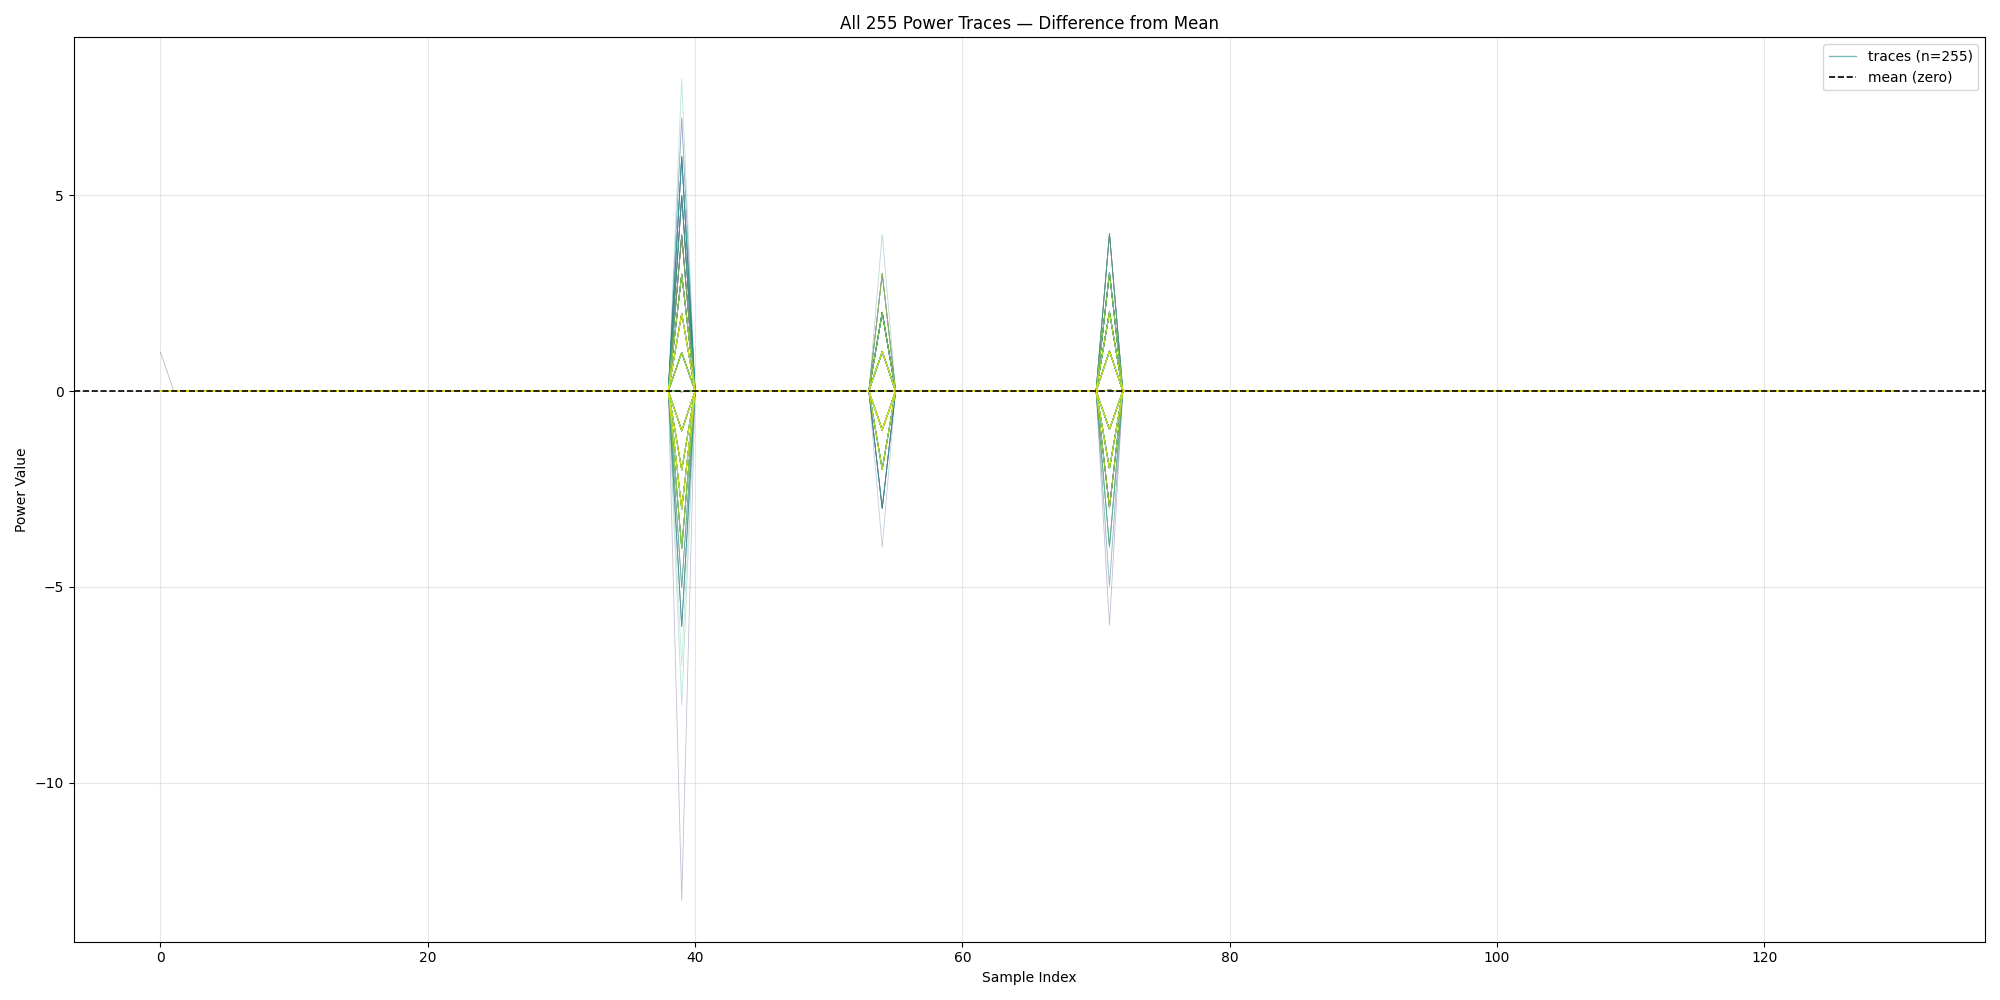

(<Figure size 2000x1000 with 1 Axes>,
 <Axes: title={'center': 'All 255 Power Traces — Difference from Mean'}, xlabel='Sample Index', ylabel='Power Value'>)

In [4]:
viewer.plot_overlay(trace_data, subtract_mean=True, baseline=True,
                    xlabel="Sample Index",
                    title=f"All {len(trace_data)} Power Traces — Difference from Mean")

# Explanation

In the two graphs above we see trace recordings from our emulator. First and foremost we can notice that they are very similar, and only differ on 3 clock cycles (which can be observed best in the second graphic). These differences depend partly on the Hamming distance between the input and output of the SBox substitution described above. These are also the parts of the calculation we try to attack when using DPA or CPA. In both of these attacks we abuse the fact that, in unsecured AES implementations, the power draw is significantly higher when more bits change state, and is approximately linearly dependent on the number of bits changed. The SBox is a strongly non-linear function, and it is the first point in the cipher where a known plaintext byte is combined with a single key byte. This lets us hypothesise each key byte independently, and the non-linearity makes a wrong key guess decorrelate sharply from the measured power. This is the property we abuse with both of these attacks. 

## Hamming Distances

The graph below will show how different Hamming distances are directly observable from our power trace. For this we calculate, for each trace, the Hamming distance between the input and output of the SBox (equivalently, the Hamming weight of their XOR) and group the traces together into groups of similar Hamming distance. This then demonstrates that, in our simple example, there are big differences in the power draw between these groups which make our attacks possible. 


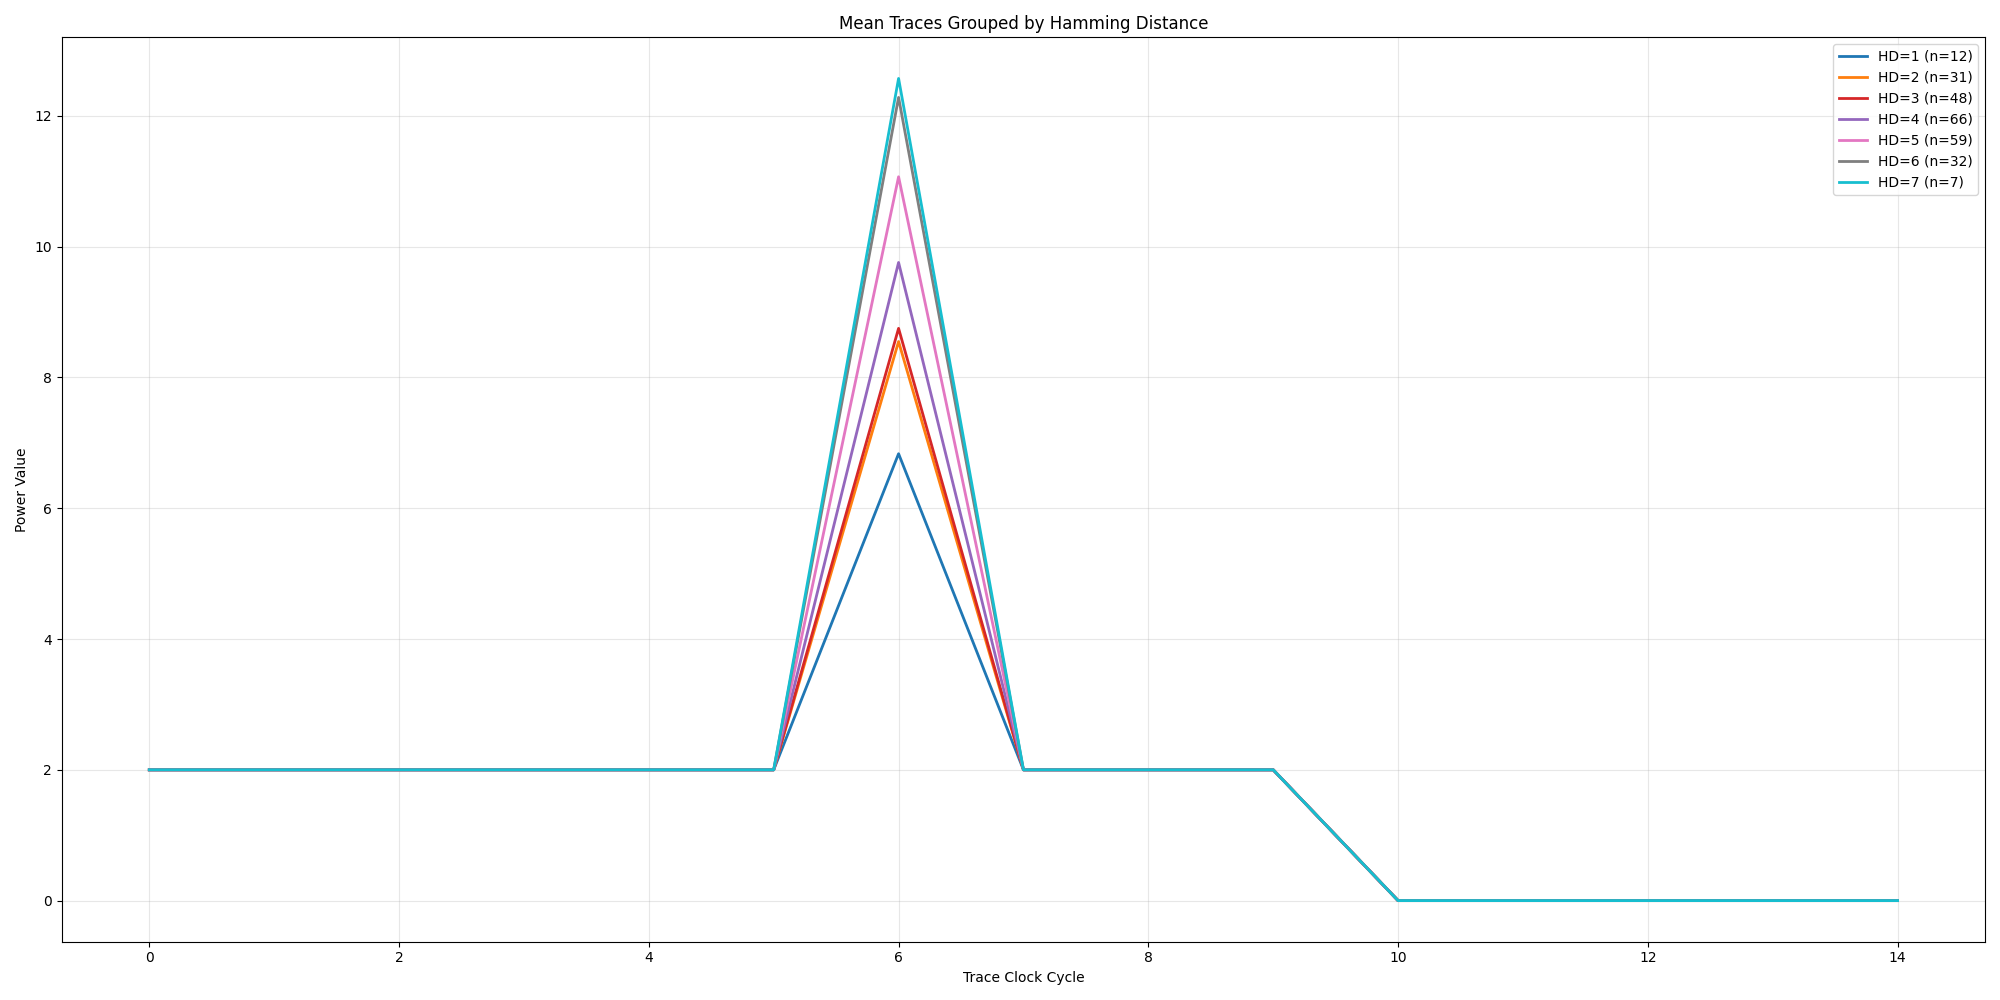

# Explanation

If we look closely into the graph we can observe the property that is used by DPA and CPA (as well as other attacks based on the same principle) to break AES. Namely, the fact that bigger Hamming weight swings result in higher power draw. Hamming weight groups 7 and 6 are at the top, followed by 5, then 4, then a grouping of 3 and 2, and finally the lowest peak is at 1.

We can only observe these differences so clearly because our power traces stem from an emulator that has no real physical properties. While you could also observe similar things from real power traces from real hardware, we should note that with a very controlled environment like our emulator we can get a much better view of the data. 

Recall that the overlay plots earlier showed differences across **3 clock cycles**. Only one of those — the SBox substitution we just grouped by Hamming distance — exhibits the leakage structure shown above. The other two differing cycles show no measurable dependence on the Hamming distance and are not part of what DPA/CPA exploit.

# Differential-Power-Analysis Attack

Now that we have seen the basis for our attacks, we are going to dive into the attacks themselves.:

DPA exploits the data-dependence of power consumption in a device executing a cryptographic operation. For a known input, a key-dependent intermediate value `v = f(input, k_guess)` leaks through power (in our case we abuse the SBox as described above). A leakage model (e.g. Hamming weight of an S-box output) predicts the leakage; the correct `k_guess` produces predictions that correlate with measured traces, wrong guesses do not.

In binning DPA (Kocher's original difference-of-means), traces are partitioned into bins by the model's predicted value, then per-bin mean traces are subtracted. The correct key guess yields a difference trace with a clear spike at the leakage sample; wrong guesses give noise.

## Attack plan

1. Acquire `N` power traces `T[i, t]` with known plaintexts `P[i]`, fixed unknown key `k*`.
2. Choose a target intermediate `v = f(P[i], k)`. The exact form of `f` has to match whatever the implementation under attack actually leaks around the SBox, so read the `SubBytes` code in `micro_aes.c` and derive `v` from it.
3. Define the leakage model as `L = LSB(v)` (LSB = Least significant bit)
4. For each key candidate `k ∈ [0, 255]`:
   - Compute predicted leakage `L[i] = LSB(v(P[i], k))` for all `i` traces.
   - Bin traces: e.g. two bins `B0 = {i : L[i] = 0}`, `B1 = {i : L[i] = 1}` (because we have chosen LSB as our leakage model).
   - Compute `Δ[t] = mean(T[B1, t]) − mean(T[B0, t])`.
   - Score `k` by `max_t |Δ[t]|` (or peak SNR).
5. Rank candidates; the correct subkey byte maximises the score.

For the emulator if we disable random_noise, 256 (1 for each possible input plaintext byte) should be sufficient to execute DPA.

In [ ]:
from src.power import  SBOX, TraceLoader

### Here you should add code to format the data correctly

loader = TraceLoader("./traces/") 
traces = loader.load_trace_data()

# You should insert code here to transform the trace data into a list of
# (input_byte, trace) tuples — one per trace — matching what DPAAttack / CPAAttack expect.
# The input byte comes from each TraceData's `metadata` dict (the input the implementation was called with).

def intermediate_value(input_byte, key_guess):
    # Please insert the correct intermediate value below. The intermediate value we chose MUST reflect how the actual implementation
    # calculates the value we want to attack. To build the correct value look into the SubBytes function in micro_aes.c.
    # You can directly derive the formula for our intermediate value from reading the code in micro_aes.c. 
    raise NotImplementedError

# 
#
# Implement the attack described above here below and use your defined intermediate_value function function
#
#

As we can see, the DPA attack recovered the correct key byte.  Now we can also see that there are several other values that are quite near the value we have identified as our key. This can always happen, especially if we work with real hardware, so it is always important to keep this in mind. ** If the attack has not recovered the key** several reasons for this are possible. The most likely is that you have not limited yourself to the first round of AES. You can either limit yourself to the first round by modifying the AES SubBytes trace syscalls or by limiting the traces itself to the first 250 cycles roughly. Or you could skip to the CPA case, which is much more robust even when using complete traces.

## Note


If you'd rather not derive `v` from scratch by reading `micro_aes.c`, you have two easy alternatives:

You can use the helper from `src.power` which ships an `aes_internal(input_byte, key_byte)` function whose formula matches what the bundled micro-AES build actually leaks around the SBox. Import it (`from src.power import aes_internal`) and use it directly as your `intermediate_value`. The other choice is to match the textbook "HW of SBox output" model instead. Modify the `SubBytes` step in `micro_aes.c` so that the value written into the state is just `SBox(input ⊕ key)` — for example `zero_array[i] = SBOX[key ^ plain];`. Once the implementation leaks that value, your `intermediate_value` is simply `SBOX[input_byte ^ key_guess]`.

Whichever path you pick, the rest of the attack stays the same. Just make sure the model in `intermediate_value` matches what your AES build is actually leaking.

If you'd rather not implement the attack from scratch, you can use the `DPAAttack` class provided by the power module of the emulator. You can use it by adding it inside the `from src.power import ...` statement. Consult the API documentation offered by the emulator to find out how to use it.

# CPA Attack 

Now that we have used a DPA attack, let's try to use a CPA attack to achieve similar results. 

CPA replaces DPA's binning with Pearson correlation between modeled leakage and measured traces. For each key candidate `k`, compute a hypothetical leakage `L[i] = model(v(P[i], k))` and correlate the vector `L` against each time sample column `T[:, t]`. The correct key produces a correlation peak; wrong keys remain near zero. CPA uses all traces jointly (not split into bins), giving higher SNR and faster convergence than binning DPA.

## Attack plan

1. Acquire `N` traces `T[i, t]`, known plaintexts `P[i]`, fixed unknown key `k*`.
2. Choose a target intermediate `v = f(P[i], k)` — the same one you derived for the DPA attack above (see the *"picking the leakage model"* note in the DPA section if you'd rather not derive it yourself).
3. Leakage model: `L[i, k] = HW(v)`. (HW is the Hamming weight of v)
4. For each `k ∈ [0, 255]`:
   - Build prediction vector `L[:, k]` of length `N`.
   - Compute `ρ[k, t] = pearson(L[:, k], T[:, t])` for all samples `t`.
   - Score: `s[k] = max_t |ρ[k, t]|`.
5. Recover byte: `k_hat = argmax_k s[k]`.

The pearson correlation coefficient for our case is defined by: 

$$
 \rho[k,t] =\frac{\sum_{i=1}^{N} \bigl(L[i,k] - \bar{L}_k\bigr)\bigl(T_{i,t} - \bar{T}_t\bigr)}{\sqrt{\sum_{i=1}^{N} \bigl(L[i,k] - \bar{L}_k\bigr)^2 \; \sum_{i=1}^{N} \bigl(T_{i,t} - \bar{T}_t\bigr)^2}} 
$$



In [ ]:
#
#
# Reuse the  intermediate_value function and the data  from above
# to implement the attack plan outlined in the cell above and 
# print its values. You will see that with the correct implementation
# You will also get the correct key  byte
#
#

## Note

As with the DPA case, if you have trouble you can use a CPAAttack class from the `src.power` module in the emulator to execute the attack. Also, if you'd just like a hint on how to implement the formula in the attack plan, you can look at the actual code of the class.

# Countermeasures

While these examples in themselves showed us what we are attacking and why it works, we will now introduce a simple countermeasure against these types of attacks, namely random delay. For this please modify the micro-AES implementation by using the trace_delay system call of the emulator. You should insert this system call immediately before the SBox operation starts, inside your tracing window. Once you have done that you should recreate your trace data, by rerunning the emulator.

## Note 

If you have issues compiling the micro-AES implementation, or you'd rather skip that step, you can use the prebuilt program in the demo-power directory of this repository.

In [ ]:
%matplotlib widget 
trace_data = np.load("backup-traces/example-traces-delay-no-noise.npy")

viewer.plot_overlay(trace_data, title=f"All {len(trace_data)} delayed power traces")

In the above example we can now see what happens when we introduce a delay into the calculation of the AES SBox substitution. The peaks that were perfectly aligned before are now stretched out and no longer synchronous. This will make DPA as well as CPA in their most basic forms ineffective. Let's demonstrate this by trying to run the code we have written above, to basically rerun both attacks against this new data set.

In [ ]:
from src.power import DPAAttack, SBOX

### Here you should add code to format the data correctly

input_data = []


def leakage_model(input_byte, key_guess):
    return input_byte ^ key_guess ^ SBOX[input_byte ^ key_guess]

dpa = DPAAttack(input_data, leakage_model)

result = dpa.attack()

for r in range(len(result)):
    print(f"{r:02x} keyguess, guess estimate: {result[r]}")

We can see now that the DPA attack spits out values that are all over the place, and the actual key value is not even close to the biggest difference value. Now let's do the same with CPA.

In [ ]:
cpa = CPAAttack(input_data)

result = cpa.attack() 

for r in range(len(result)):
    print(f"{r:02x} keyguess, guess estimate: {result[r]}")

Essentially we can observe the same behaviour as in our DPA case. This shows that, at least without extending the attacks, this countermeasure is effective at defending against these types of attacks. Now let's try to break this simple countermeasure by using some advanced techniques in combination with CPA. 

# Cross-correlation technique

Now, in order to get our attack to work again, we have to do some work. While the simple delay is effective at thwarting simple CPA and DPA attacks, it is by no means an effective way to defeat these types of attacks completely. In order to get our CPA attack working again, we will perform the following attack plan:

1. Select a reference trace.
2. Choose an anchor window for this trace (meaning a part of the trace we will use to realign our traces).
3. Compute the cross-correlation of all other traces against our reference trace $x$.
4. Realign all other traces with our reference trace.

This should, in theory, effectively negate the random delay, by simply realigning our traces so we are able to compute our CPA attack again. 
The formula for the cross-correlation for our example is defined as follows: 
$$R_{xy}(m)=\sum_n x[n] \cdot y[n-m]$$

where $R_{xy}$ is the cross-correlation coefficient, $x$ is our reference trace, $y$ is the target trace, $n$ is a sample index (meaning one point in time of our trace) and $m$ is the amount we need to shift the trace to get our traces $x$ and $y$ to realign.

Now, in order to implement this, we need to make an educated guess about the range of $m$, because we will basically have to search for this value. For our emulator the `trace_delay()` syscall has a range of 20 from our "base offset". That means that the syscall can insert up to 20 delay cycles. Now, if we choose the reference trace at random, we should have a search interval of $[-20,20]$ respectively, if we assume the "worst case" of choosing a reference trace with the 20 delay cycles and a "best case" of choosing a reference trace with no delay cycles.

# Hint 

Using the normalized (Pearson) cross-correlation is much easier in practice instead of using the simple formula above. The formula for this was defined above and can be adjusted for our use case quite easily. Another definition of this formula can be found here -> https://en.wikipedia.org/wiki/Pearson_correlation_coefficient


In [ ]:
# 
#
#
# Use this code cell to implement the cross-correlation technique
# First plot your reference trace and define the anchor window you want to use 
# Then compute the cross-correlation using your reference trace window for all other traces
# and shift them by the shift value with the best correlation. Then use the shifted traces
# and feed them to the CPAAttack class. This should then spit out the correct value for the key 
# byte again.
#
#

# Result

As we can see above, our attack was successful again, even when using a delay, by realigning the traces. 